# Reinforcement Learning: Interactive Theory

> *"The Bellman equation is the spine of RL — every algorithm is either solving it exactly (DP), approximating it with samples (TD), or bypassing it entirely (policy gradient)."*

This notebook provides interactive demonstrations of the core RL algorithms. We implement everything from scratch using only NumPy, verify theoretical results numerically, and visualise the learning process.

**Sections:**
1. Setup
2. GridWorld Environment
3. Value Iteration and Policy Iteration
4. TD(0) vs Monte Carlo Prediction
5. Q-Learning and SARSA
6. TD(lambda) with Eligibility Traces
7. REINFORCE (Policy Gradient)
8. Actor-Critic
9. PPO (Simplified)
10. Double Q-Learning vs Q-Learning
11. Exploration: UCB vs Epsilon-Greedy
12. DPO Loss Landscape
13. Reward Modelling (Bradley-Terry)

In [2]:
import numpy as np
import numpy.linalg as la

try:
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    try:
        import seaborn as sns
        sns.set_theme(style='whitegrid', palette='colorblind')
        HAS_SNS = True
    except ImportError:
        plt.style.use('seaborn-v0_8-whitegrid')
        HAS_SNS = False
    mpl.rcParams.update({
        'figure.figsize': (10, 6),
        'figure.dpi': 120,
        'font.size': 13,
        'axes.titlesize': 15,
        'axes.labelsize': 13,
        'lines.linewidth': 2.0,
        'axes.spines.top': False,
        'axes.spines.right': False,
    })
    HAS_MPL = True
except ImportError:
    HAS_MPL = False

COLORS = {
    'primary': '#0077BB',
    'secondary': '#EE7733',
    'tertiary': '#009988',
    'quaternary': '#CC3311',
    'quinary': '#33BBEE',
}

np.random.seed(42)
print("Setup complete.")

Setup complete.


## 2. GridWorld Environment

A configurable gridworld MDP for testing RL algorithms. The agent navigates a grid, receiving -0.01 per step and +1.0 at the goal.

In [3]:
class GridWorld:
    """Simple gridworld MDP."""

    def __init__(self, size=5, start=(0, 0), goal=None, obstacles=None):
        self.h, self.w = size, size
        self.start = start
        self.goal = goal or (size-1, size-1)
        self.obstacles = obstacles or []
        self.n_states = self.h * self.w
        self.n_actions = 4  # up, down, left, right
        self.action_effects = [(-1, 0), (1, 0), (0, -1), (0, 1)]
        self.state = None
        self.reset()

    def pos_to_s(self, pos): return pos[0] * self.w + pos[1]
    def s_to_pos(self, s): return (s // self.w, s % self.w)

    def reset(self):
        self.state = self.start
        return self.pos_to_s(self.state)

    def step(self, action):
        dy, dx = self.action_effects[action]
        ny, nx = self.state[0] + dy, self.state[1] + dx
        if 0 <= ny < self.h and 0 <= nx < self.w and (ny, nx) not in self.obstacles:
            self.state = (ny, nx)
        done = self.state == self.goal
        reward = 1.0 if done else -0.01
        return self.pos_to_s(self.state), reward, done

    def get_transitions(self, s, a):
        pos = self.s_to_pos(s)
        if pos == self.goal:
            return [(s, 1.0, 0.0)]
        dy, dx = self.action_effects[a]
        ny, nx = pos[0] + dy, pos[1] + dx
        if 0 <= ny < self.h and 0 <= nx < self.w and (ny, nx) not in self.obstacles:
            ns = self.pos_to_s((ny, nx))
            r = 1.0 if (ny, nx) == self.goal else -0.01
            return [(ns, 1.0, r)]
        return [(s, 1.0, -0.01)]

env = GridWorld(size=5)
print(f"GridWorld: {env.h}x{env.w}, {env.n_states} states, {env.n_actions} actions")
print(f"Start: {env.start}, Goal: {env.goal}")

GridWorld: 5x5, 25 states, 4 actions
Start: (0, 0), Goal: (4, 4)


## 3. Value Iteration and Policy Iteration

**Value iteration** applies the Bellman optimality backup:
$$V_{k+1}(s) = \max_a \sum_{s'} P(s'|s,a)[R + \gamma V_k(s')]$$

We implement both and compare convergence.

In [4]:
def value_iteration(env, gamma=0.99, theta=1e-8):
    """Value iteration with convergence tracking."""
    V = np.zeros(env.n_states)
    history = []

    for it in range(1000):
        V_new = np.zeros_like(V)
        for s in range(env.n_states):
            if env.s_to_pos(s) == env.goal:
                continue
            q_vals = []
            for a in range(env.n_actions):
                q = sum(p * (r + gamma * V[ns]) for ns, p, r in env.get_transitions(s, a))
                q_vals.append(q)
            V_new[s] = max(q_vals)

        delta = np.max(np.abs(V_new - V))
        history.append(delta)
        V = V_new
        if delta < theta:
            break

    # Extract policy
    policy = np.zeros(env.n_states, dtype=int)
    for s in range(env.n_states):
        q_vals = []
        for a in range(env.n_actions):
            q = sum(p * (r + gamma * V[ns]) for ns, p, r in env.get_transitions(s, a))
            q_vals.append(q)
        policy[s] = np.argmax(q_vals)

    return V, policy, history

def policy_iteration(env, gamma=0.99, theta=1e-8):
    """Policy iteration with convergence tracking."""
    policy = np.random.randint(0, env.n_actions, size=env.n_states)
    history = []

    for outer in range(100):
        # Policy evaluation
        V = np.zeros(env.n_states)
        for _ in range(1000):
            delta = 0
            for s in range(env.n_states):
                if env.s_to_pos(s) == env.goal:
                    continue
                v_old = V[s]
                a = policy[s]
                V[s] = sum(p * (r + gamma * V[ns]) for ns, p, r in env.get_transitions(s, a))
                delta = max(delta, abs(V[s] - v_old))
            if delta < theta:
                break

        # Policy improvement
        stable = True
        for s in range(env.n_states):
            old_a = policy[s]
            q_vals = []
            for a in range(env.n_actions):
                q = sum(p * (r + gamma * V[ns]) for ns, p, r in env.get_transitions(s, a))
                q_vals.append(q)
            policy[s] = np.argmax(q_vals)
            if old_a != policy[s]:
                stable = False

        history.append(outer)
        if stable:
            break

    return V, policy, len(history)

# Run both
env = GridWorld(size=5)
V_vi, pi_vi, vi_hist = value_iteration(env)
V_pi, pi_pi, pi_iters = policy_iteration(env)

print(f"Value iteration converged in {len(vi_hist)} iterations")
print(f"Policy iteration converged in {pi_iters} iterations")
print(f"Max value difference: {np.max(np.abs(V_vi - V_pi)):.2e}")

# Display
arrows = ['\u2191', '\u2193', '\u2190', '\u2192']
print("\nOptimal Value Function:")
for i in range(env.h):
    row = " ".join(f"{V_vi[i*env.w+j]:6.2f}" for j in range(env.w))
    print(f"  {row}")

print("\nOptimal Policy:")
for i in range(env.h):
    row = "  ".join(arrows[pi_vi[i*env.w+j]] if (i,j) != env.goal else 'G'
                     for j in range(env.w))
    print(f"  {row}")

Value iteration converged in 9 iterations
Policy iteration converged in 7 iterations
Max value difference: 0.00e+00

Optimal Value Function:
    0.86   0.88   0.90   0.92   0.94
    0.88   0.90   0.92   0.94   0.96
    0.90   0.92   0.94   0.96   0.98
    0.92   0.94   0.96   0.98   1.00
    0.94   0.96   0.98   1.00   0.00

Optimal Policy:
  ↓  ↓  ↓  ↓  ↓
  ↓  ↓  ↓  ↓  ↓
  ↓  ↓  ↓  ↓  ↓
  ↓  ↓  ↓  ↓  ↓
  →  →  →  →  G


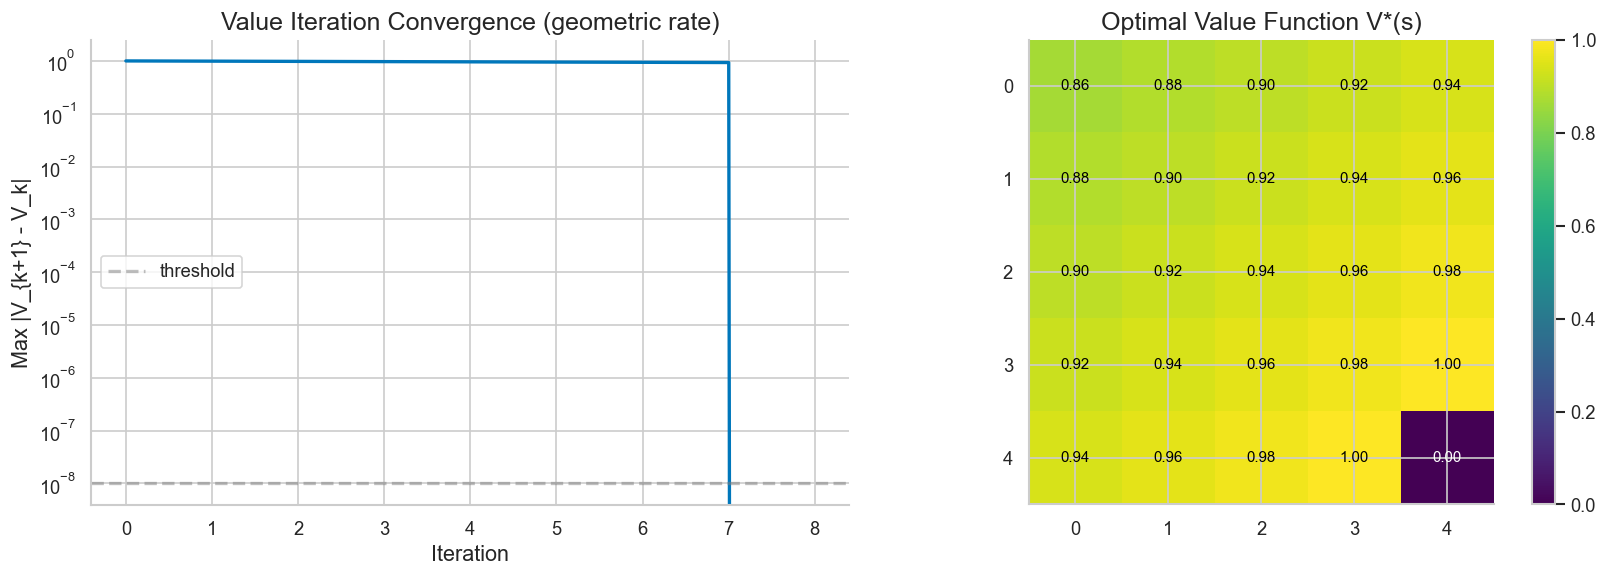

In [5]:
if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Value iteration convergence
    axes[0].semilogy(vi_hist, color=COLORS['primary'], linewidth=2)
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Max |V_{k+1} - V_k|')
    axes[0].set_title('Value Iteration Convergence (geometric rate)')
    axes[0].axhline(y=1e-8, color='gray', linestyle='--', alpha=0.5, label='threshold')
    axes[0].legend()

    # Value function heatmap
    V_grid = V_vi.reshape(env.h, env.w)
    im = axes[1].imshow(V_grid, cmap='viridis', interpolation='nearest')
    axes[1].set_title('Optimal Value Function V*(s)')
    plt.colorbar(im, ax=axes[1])
    for i in range(env.h):
        for j in range(env.w):
            axes[1].text(j, i, f'{V_grid[i,j]:.2f}', ha='center', va='center',
                        color='white' if V_grid[i,j] < 0.5 else 'black', fontsize=9)

    plt.tight_layout()
    plt.show()

## 4. TD(0) vs Monte Carlo Prediction

We compare TD(0) and Monte Carlo on a random walk (5 states + 2 terminal).
- TD(0) bootstraps: lower variance, biased.
- MC uses full returns: unbiased, higher variance.

In [6]:
class RandomWalk:
    """5-state random walk. Terminal states at 0 and 6."""
    def __init__(self):
        self.n_states = 7  # 0 and 6 are terminal
        self.state = 3     # Start in middle

    def reset(self):
        self.state = 3
        return self.state

    def step(self):
        if np.random.random() < 0.5:
            self.state -= 1  # left
        else:
            self.state += 1  # right
        done = self.state == 0 or self.state == 6
        reward = 1.0 if self.state == 6 else 0.0
        return self.state, reward, done

# True values (analytical)
true_V = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])

def td0_prediction(env, alpha=0.1, n_episodes=100, n_runs=50):
    """TD(0) prediction with multiple runs."""
    all_rmse = np.zeros((n_runs, n_episodes))
    for run in range(n_runs):
        V = np.full(7, 0.5)
        V[0] = V[6] = 0
        for ep in range(n_episodes):
            s = env.reset()
            while True:
                ns, r, done = env.step()
                V[s] += alpha * (r + (0 if done else V[ns]) - V[s])
                s = ns
                if done:
                    break
            rmse = np.sqrt(np.mean((V[1:6] - true_V[1:6])**2))
            all_rmse[run, ep] = rmse
    return np.mean(all_rmse, axis=0)

def mc_prediction(env, alpha=0.1, n_episodes=100, n_runs=50):
    """First-visit MC prediction with multiple runs."""
    all_rmse = np.zeros((n_runs, n_episodes))
    for run in range(n_runs):
        V = np.full(7, 0.5)
        V[0] = V[6] = 0
        for ep in range(n_episodes):
            s = env.reset()
            states = [s]
            rewards = []
            while True:
                ns, r, done = env.step()
                rewards.append(r)
                states.append(ns)
                if done:
                    break
            G = 0
            for t in reversed(range(len(rewards))):
                G = rewards[t] + G
                V[states[t]] += alpha * (G - V[states[t]])
            rmse = np.sqrt(np.mean((V[1:6] - true_V[1:6])**2))
            all_rmse[run, ep] = rmse
    return np.mean(all_rmse, axis=0)

env = RandomWalk()
td_rmse = td0_prediction(env, alpha=0.1)
mc_rmse = mc_prediction(env, alpha=0.01)

print(f"Final RMSE - TD(0): {td_rmse[-1]:.4f}, MC: {mc_rmse[-1]:.4f}")

Final RMSE - TD(0): 0.0574, MC: 0.0965


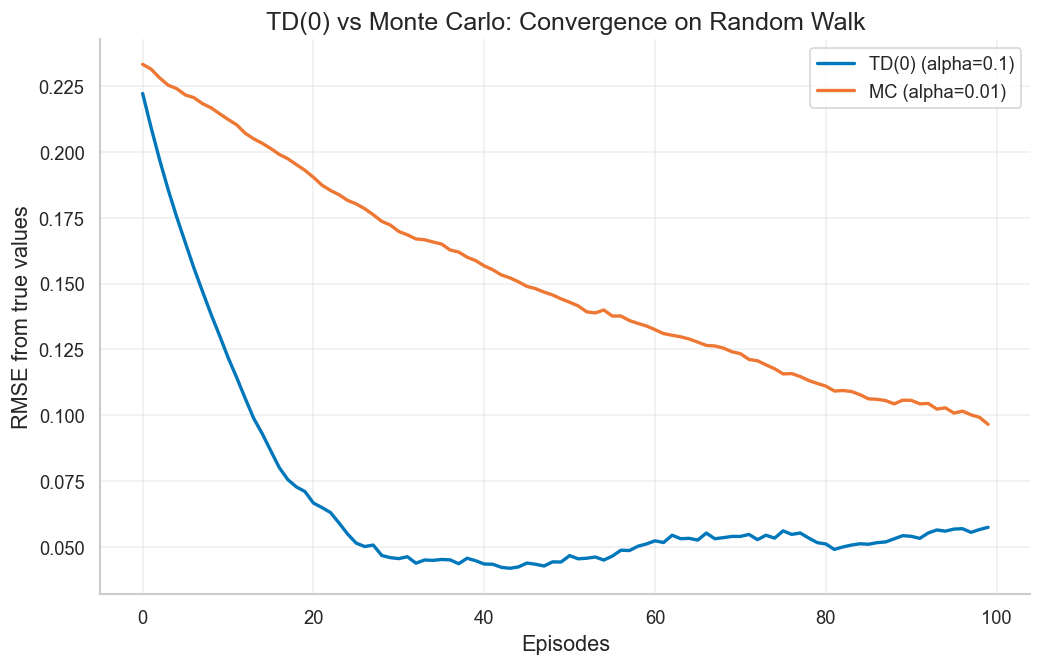

In [7]:
if HAS_MPL:
    plt.figure(figsize=(10, 6))
    plt.plot(td_rmse, label='TD(0) (alpha=0.1)', color=COLORS['primary'])
    plt.plot(mc_rmse, label='MC (alpha=0.01)', color=COLORS['secondary'])
    plt.xlabel('Episodes')
    plt.ylabel('RMSE from true values')
    plt.title('TD(0) vs Monte Carlo: Convergence on Random Walk')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 5. Q-Learning and SARSA

We compare Q-learning (off-policy) and SARSA (on-policy) on a gridworld.
Q-learning learns the optimal policy regardless of exploration; SARSA learns the value of the policy being followed.

In [8]:
def q_learning(env, n_episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = np.zeros((env.n_states, env.n_actions))
    rewards = []
    for ep in range(n_episodes):
        s = env.reset()
        total_r = 0
        for _ in range(500):
            a = np.random.randint(env.n_actions) if np.random.random() < epsilon else np.argmax(Q[s])
            ns, r, done = env.step(a)
            Q[s, a] += alpha * (r + gamma * np.max(Q[ns]) * (1-done) - Q[s, a])
            total_r += r
            s = ns
            if done: break
        rewards.append(total_r)
    return Q, rewards

def sarsa(env, n_episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = np.zeros((env.n_states, env.n_actions))
    rewards = []
    for ep in range(n_episodes):
        s = env.reset()
        a = np.random.randint(env.n_actions) if np.random.random() < epsilon else np.argmax(Q[s])
        total_r = 0
        for _ in range(500):
            ns, r, done = env.step(a)
            na = np.random.randint(env.n_actions) if np.random.random() < epsilon else np.argmax(Q[ns])
            Q[s, a] += alpha * (r + gamma * Q[ns, na] * (1-done) - Q[s, a])
            total_r += r
            s, a = ns, na
            if done: break
        rewards.append(total_r)
    return Q, rewards

env = GridWorld(size=5)
Q_ql, r_ql = q_learning(env)
Q_sa, r_sa = sarsa(env)

# Smooth rewards
window = 20
r_ql_smooth = np.convolve(r_ql, np.ones(window)/window, mode='valid')
r_sa_smooth = np.convolve(r_sa, np.ones(window)/window, mode='valid')

print(f"Q-learning final avg reward: {np.mean(r_ql[-50:]):.3f}")
print(f"SARSA final avg reward: {np.mean(r_sa[-50:]):.3f}")

Q-learning final avg reward: 0.919
SARSA final avg reward: 0.919


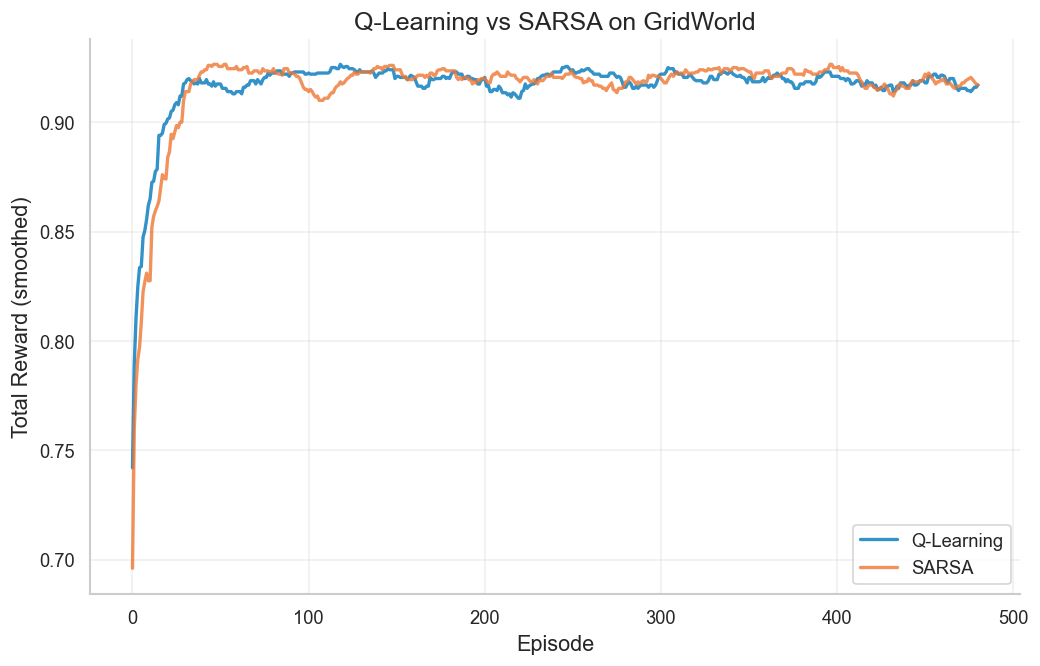

In [9]:
if HAS_MPL:
    plt.figure(figsize=(10, 6))
    plt.plot(r_ql_smooth, label='Q-Learning', color=COLORS['primary'], alpha=0.8)
    plt.plot(r_sa_smooth, label='SARSA', color=COLORS['secondary'], alpha=0.8)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward (smoothed)')
    plt.title('Q-Learning vs SARSA on GridWorld')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 7. REINFORCE (Policy Gradient)

REINFORCE uses Monte Carlo returns to estimate the policy gradient:
$$\theta \leftarrow \theta + \alpha \sum_t \gamma^t G_t \nabla_\theta \log \pi_\theta(a_t|s_t)$$

In [10]:
class REINFORCE:
    def __init__(self, n_states, n_actions, lr=0.01, gamma=0.99):
        self.theta = np.zeros((n_states, n_actions))
        self.lr = lr
        self.gamma = gamma

    def softmax(self, s):
        logits = self.theta[s]
        e = np.exp(logits - np.max(logits))
        return e / e.sum()

    def act(self, s):
        return np.random.choice(len(self.softmax(s)), p=self.softmax(s))

    def update(self, states, actions, rewards):
        T = len(rewards)
        G = np.zeros(T)
        G[-1] = rewards[-1]
        for t in range(T-2, -1, -1):
            G[t] = rewards[t] + self.gamma * G[t+1]

        for t in range(T):
            probs = self.softmax(states[t])
            grad = -probs.copy()
            grad[actions[t]] += 1
            self.theta[states[t]] += self.lr * (self.gamma**t) * G[t] * grad

    def train(self, env, n_episodes=1000):
        history = []
        for ep in range(n_episodes):
            s = env.reset()
            states, actions, rewards = [], [], []
            for _ in range(500):
                a = self.act(s)
                ns, r, done = env.step(a)
                states.append(s); actions.append(a); rewards.append(r)
                s = ns
                if done: break
            self.update(states, actions, rewards)
            history.append(sum(rewards))
        return history

env = GridWorld(size=4)
agent = REINFORCE(env.n_states, env.n_actions, lr=0.01)
rf_rewards = agent.train(env, n_episodes=1000)

rf_smooth = np.convolve(rf_rewards, np.ones(50)/50, mode='valid')
print(f"REINFORCE final avg reward: {np.mean(rf_rewards[-50:]):.3f}")

REINFORCE final avg reward: 0.804


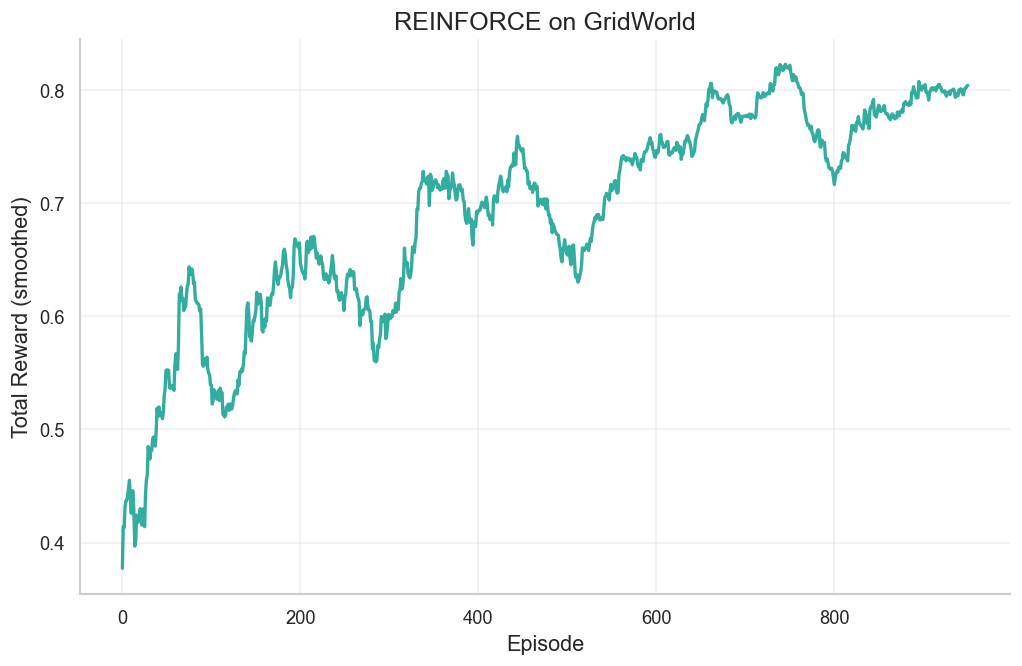

In [11]:
if HAS_MPL:
    plt.figure(figsize=(10, 6))
    plt.plot(rf_smooth, color=COLORS['tertiary'], alpha=0.8)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward (smoothed)')
    plt.title('REINFORCE on GridWorld')
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. Double Q-Learning vs Q-Learning

Standard Q-learning overestimates values due to the max operator.
Double Q-learning uses two independent Q-functions to decouple selection and evaluation.

In [12]:
class MaxBiasEnv:
    """Environment demonstrating maximisation bias.
    State A: left -> terminal(0), right -> B
    State B: 10 actions with N(-0.1, 1) reward -> terminal"""

    def __init__(self):
        self.state = 'A'

    def reset(self):
        self.state = 'A'
        return self.state

    def step(self, action):
        if self.state == 'A':
            if action == 0:  # left
                return 'terminal', 0.0, True
            else:
                self.state = 'B'
                return 'B', 0.0, False
        else:
            return 'terminal', np.random.normal(-0.1, 1.0), True

def run_max_bias_experiment(n_episodes=300, n_runs=100):
    ql_left = np.zeros((n_runs, n_episodes))
    dql_left = np.zeros((n_runs, n_episodes))

    for run in range(n_runs):
        env = MaxBiasEnv()

        # Q-learning
        Q_A = np.zeros(2)
        Q_B = np.zeros(10)
        for ep in range(n_episodes):
            s = env.reset()
            while True:
                if s == 'A':
                    a = np.random.randint(2) if np.random.random() < 0.1 else np.argmax(Q_A)
                    ns, r, done = env.step(a)
                    if ns == 'terminal':
                        Q_A[a] += 0.1 * (r - Q_A[a])
                    else:
                        Q_A[a] += 0.1 * (r + np.max(Q_B) - Q_A[a])
                else:
                    a = np.random.randint(10) if np.random.random() < 0.1 else np.argmax(Q_B)
                    ns, r, done = env.step(a)
                    Q_B[a] += 0.1 * (r - Q_B[a])
                s = ns
                if done: break
            ql_left[run, ep] = 1.0 if np.argmax(Q_A) == 0 else 0.0

        # Double Q-learning
        Q1_A, Q2_A = np.zeros(2), np.zeros(2)
        Q1_B, Q2_B = np.zeros(10), np.zeros(10)
        for ep in range(n_episodes):
            s = env.reset()
            while True:
                if s == 'A':
                    Qsum = Q1_A + Q2_A
                    a = np.random.randint(2) if np.random.random() < 0.1 else np.argmax(Qsum)
                    ns, r, done = env.step(a)
                    if np.random.random() < 0.5:
                        if ns == 'terminal':
                            Q1_A[a] += 0.1 * (r - Q1_A[a])
                        else:
                            Q1_A[a] += 0.1 * (r + Q2_B[np.argmax(Q1_B)] - Q1_A[a])
                    else:
                        if ns == 'terminal':
                            Q2_A[a] += 0.1 * (r - Q2_A[a])
                        else:
                            Q2_A[a] += 0.1 * (r + Q1_B[np.argmax(Q2_B)] - Q2_A[a])
                else:
                    Qsum = Q1_B + Q2_B
                    a = np.random.randint(10) if np.random.random() < 0.1 else np.argmax(Qsum)
                    ns, r, done = env.step(a)
                    if np.random.random() < 0.5:
                        Q1_B[a] += 0.1 * (r - Q1_B[a])
                    else:
                        Q2_B[a] += 0.1 * (r - Q2_B[a])
                s = ns
                if done: break
            dql_left[run, ep] = 1.0 if np.argmax(Q1_A + Q2_A) == 0 else 0.0

    return np.mean(ql_left, axis=0), np.mean(dql_left, axis=0)

ql_pct, dql_pct = run_max_bias_experiment()
print(f"Optimal action (left) chosen (final 50 eps):")
print(f"  Q-learning: {100*np.mean(ql_pct[-50:]):.1f}%")
print(f"  Double Q-learning: {100*np.mean(dql_pct[-50:]):.1f}%")

Optimal action (left) chosen (final 50 eps):
  Q-learning: 91.2%
  Double Q-learning: 99.3%


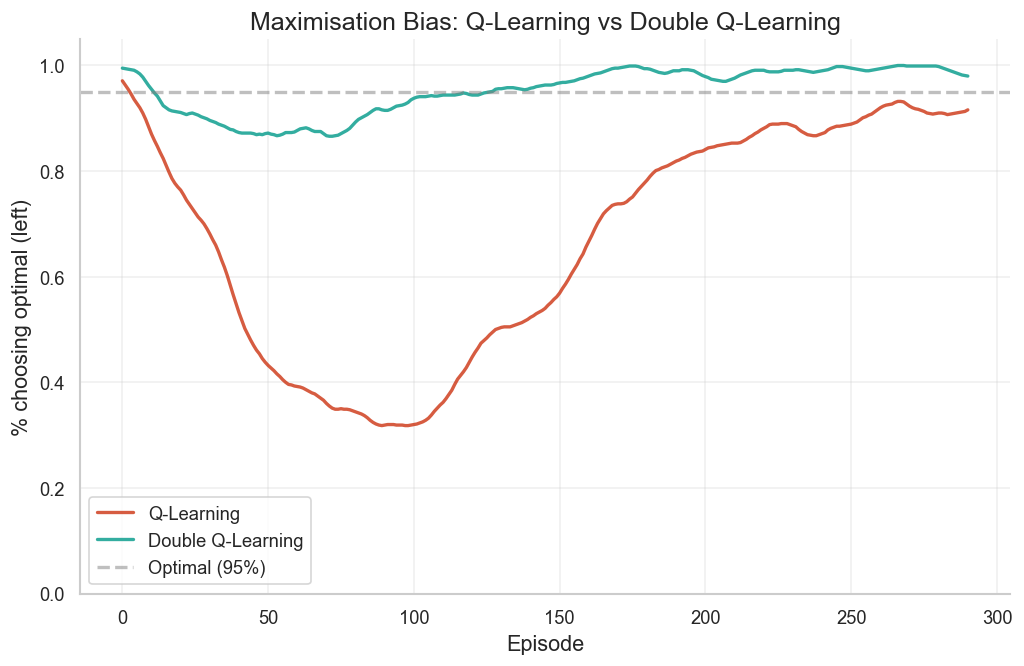

In [13]:
if HAS_MPL:
    plt.figure(figsize=(10, 6))
    w = 10
    plt.plot(np.convolve(ql_pct, np.ones(w)/w, 'valid'), label='Q-Learning',
             color=COLORS['quaternary'], alpha=0.8)
    plt.plot(np.convolve(dql_pct, np.ones(w)/w, 'valid'), label='Double Q-Learning',
             color=COLORS['tertiary'], alpha=0.8)
    plt.axhline(y=0.95, color='gray', linestyle='--', alpha=0.5, label='Optimal (95%)')
    plt.xlabel('Episode')
    plt.ylabel('% choosing optimal (left)')
    plt.title('Maximisation Bias: Q-Learning vs Double Q-Learning')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 1.05)
    plt.show()

## 11. Exploration: UCB vs Epsilon-Greedy

UCB uses optimism in the face of uncertainty:
$$a_t = \arg\max_a \left[Q(a) + c\sqrt{\frac{\ln t}{N(a)}}\right]$$

In [14]:
class BanditEnv:
    def __init__(self, k=10):
        self.k = k
        self.means = np.random.randn(k)

    def pull(self, a):
        return self.means[a] + np.random.randn()

def run_bandit_experiment(k=10, n_steps=1000, n_runs=200):
    eps_rewards = np.zeros((n_runs, n_steps))
    ucb_rewards = np.zeros((n_runs, n_steps))

    for run in range(n_runs):
        env = BanditEnv(k)

        # Epsilon-greedy
        Q_eps = np.zeros(k)
        N_eps = np.zeros(k)
        for t in range(n_steps):
            if np.random.random() < 0.1:
                a = np.random.randint(k)
            else:
                a = np.argmax(Q_eps)
            r = env.pull(a)
            N_eps[a] += 1
            Q_eps[a] += (r - Q_eps[a]) / N_eps[a]
            eps_rewards[run, t] = r

        # UCB
        Q_ucb = np.zeros(k)
        N_ucb = np.zeros(k)
        for t in range(n_steps):
            if t < k:
                a = t  # try each arm once
            else:
                ucb_vals = Q_ucb + 2 * np.sqrt(np.log(t+1) / (N_ucb + 1e-8))
                a = np.argmax(ucb_vals)
            r = env.pull(a)
            N_ucb[a] += 1
            Q_ucb[a] += (r - Q_ucb[a]) / N_ucb[a]
            ucb_rewards[run, t] = r

    return np.mean(eps_rewards, axis=0), np.mean(ucb_rewards, axis=0)

eps_r, ucb_r = run_bandit_experiment()
print(f"Average reward (last 100 steps):")
print(f"  Epsilon-greedy: {np.mean(eps_r[-100:]):.3f}")
print(f"  UCB: {np.mean(ucb_r[-100:]):.3f}")

Average reward (last 100 steps):
  Epsilon-greedy: 1.369
  UCB: 1.478


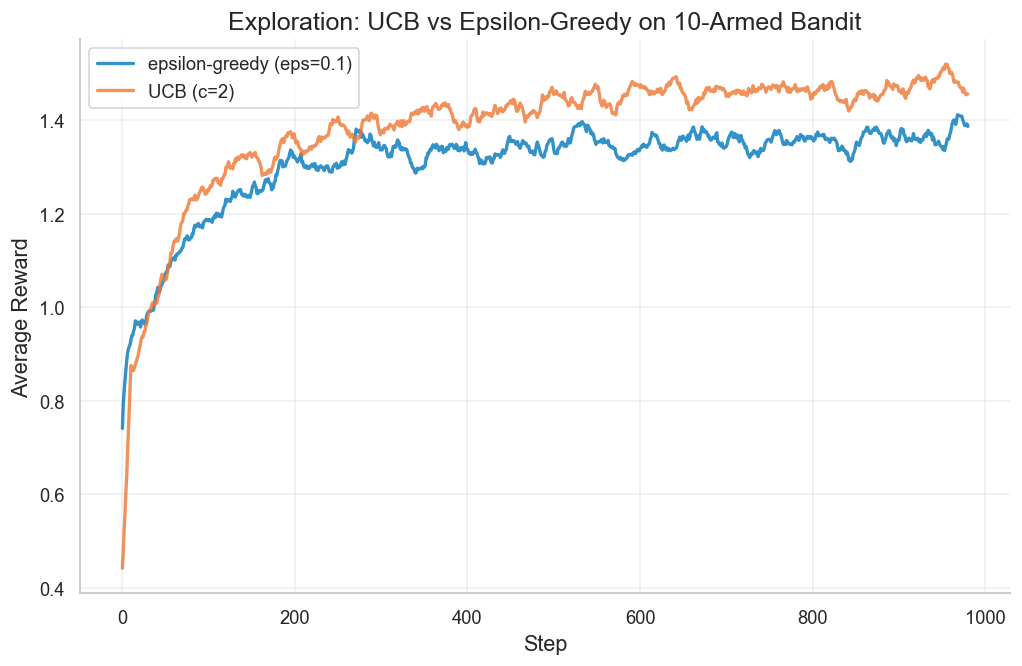

In [15]:
if HAS_MPL:
    plt.figure(figsize=(10, 6))
    w = 20
    plt.plot(np.convolve(eps_r, np.ones(w)/w, 'valid'), label='epsilon-greedy (eps=0.1)',
             color=COLORS['primary'], alpha=0.8)
    plt.plot(np.convolve(ucb_r, np.ones(w)/w, 'valid'), label='UCB (c=2)',
             color=COLORS['secondary'], alpha=0.8)
    plt.xlabel('Step')
    plt.ylabel('Average Reward')
    plt.title('Exploration: UCB vs Epsilon-Greedy on 10-Armed Bandit')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 12. DPO Loss Landscape

DPO loss as a function of the implicit reward difference $\beta \log \frac{\pi_\theta(y_w)}{\pi_{ref}(y_w)} - \beta \log \frac{\pi_\theta(y_l)}{\pi_{ref}(y_l)}$:

$$\mathcal{L}_{DPO} = -\log \sigma\left(\beta \log \frac{\pi_\theta(y_w)}{\pi_{ref}(y_w)} - \beta \log \frac{\pi_\theta(y_l)}{\pi_{ref}(y_l)}\right)$$

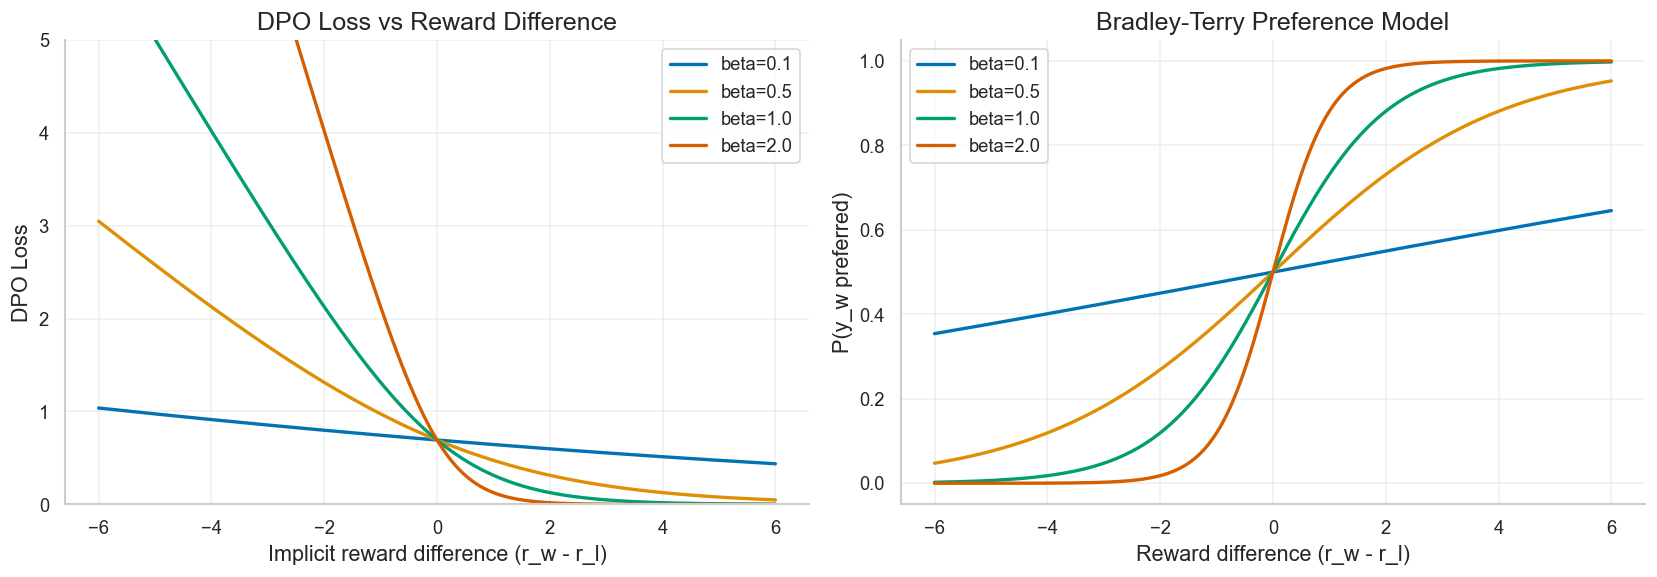

At reward_diff=0: P(preferred) = 0.5 (uncertain)
As reward_diff grows: P(preferred) -> 1 (confident)
Higher beta = sharper discrimination between good and bad


In [16]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

x = np.linspace(-6, 6, 500)

if HAS_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # DPO loss
    for beta in [0.1, 0.5, 1.0, 2.0]:
        loss = -np.log(sigmoid(beta * x) + 1e-10)
        axes[0].plot(x, loss, label=f'beta={beta}', linewidth=2)
    axes[0].set_xlabel('Implicit reward difference (r_w - r_l)')
    axes[0].set_ylabel('DPO Loss')
    axes[0].set_title('DPO Loss vs Reward Difference')
    axes[0].legend()
    axes[0].set_ylim(0, 5)
    axes[0].grid(True, alpha=0.3)

    # Bradley-Terry preference probability
    for beta in [0.1, 0.5, 1.0, 2.0]:
        prob = sigmoid(beta * x)
        axes[1].plot(x, prob, label=f'beta={beta}', linewidth=2)
    axes[1].set_xlabel('Reward difference (r_w - r_l)')
    axes[1].set_ylabel('P(y_w preferred)')
    axes[1].set_title('Bradley-Terry Preference Model')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("At reward_diff=0: P(preferred) = 0.5 (uncertain)")
    print("As reward_diff grows: P(preferred) -> 1 (confident)")
    print("Higher beta = sharper discrimination between good and bad")

## 9. PPO Clipping Visualisation

The PPO clipped objective prevents destructively large policy updates:
$$L^{CLIP} = \min(r \cdot A, \text{clip}(r, 1-\epsilon, 1+\epsilon) \cdot A)$$

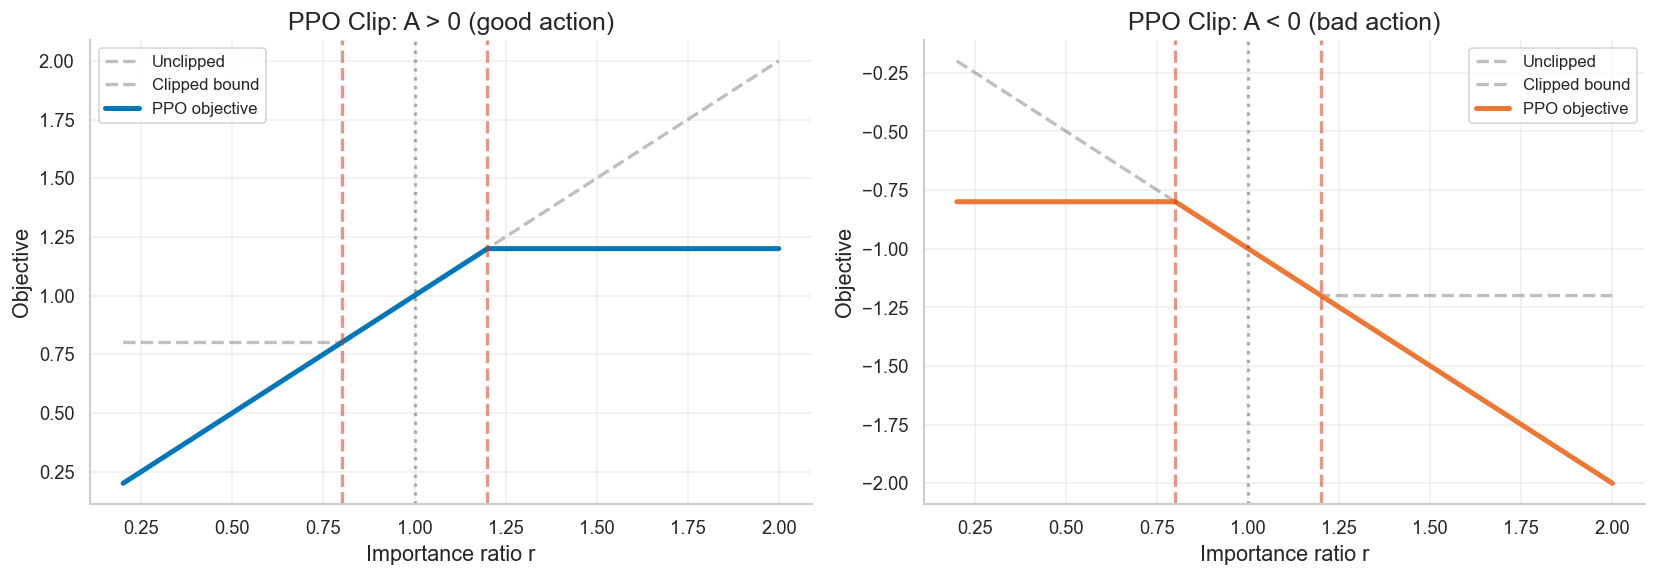

For A > 0: gradient stops when r > 1+eps (prevents over-reinforcing)
For A < 0: gradient stops when r < 1-eps (prevents over-suppressing)


In [17]:
if HAS_MPL:
    r = np.linspace(0.2, 2.0, 500)
    eps = 0.2

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # A > 0 (good action)
    A_pos = 1.0
    unclipped = r * A_pos
    clipped = np.clip(r, 1-eps, 1+eps) * A_pos
    objective = np.minimum(unclipped, clipped)

    axes[0].plot(r, unclipped, '--', color='gray', alpha=0.5, label='Unclipped')
    axes[0].plot(r, clipped, '--', color='gray', alpha=0.5, label='Clipped bound')
    axes[0].plot(r, objective, color=COLORS['primary'], linewidth=3, label='PPO objective')
    axes[0].axvline(x=1.0, color='black', linestyle=':', alpha=0.3)
    axes[0].axvline(x=1-eps, color=COLORS['quaternary'], linestyle='--', alpha=0.5)
    axes[0].axvline(x=1+eps, color=COLORS['quaternary'], linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Importance ratio r')
    axes[0].set_ylabel('Objective')
    axes[0].set_title('PPO Clip: A > 0 (good action)')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # A < 0 (bad action)
    A_neg = -1.0
    unclipped = r * A_neg
    clipped = np.clip(r, 1-eps, 1+eps) * A_neg
    objective = np.minimum(unclipped, clipped)

    axes[1].plot(r, unclipped, '--', color='gray', alpha=0.5, label='Unclipped')
    axes[1].plot(r, clipped, '--', color='gray', alpha=0.5, label='Clipped bound')
    axes[1].plot(r, objective, color=COLORS['secondary'], linewidth=3, label='PPO objective')
    axes[1].axvline(x=1.0, color='black', linestyle=':', alpha=0.3)
    axes[1].axvline(x=1-eps, color=COLORS['quaternary'], linestyle='--', alpha=0.5)
    axes[1].axvline(x=1+eps, color=COLORS['quaternary'], linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Importance ratio r')
    axes[1].set_ylabel('Objective')
    axes[1].set_title('PPO Clip: A < 0 (bad action)')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("For A > 0: gradient stops when r > 1+eps (prevents over-reinforcing)")
    print("For A < 0: gradient stops when r < 1-eps (prevents over-suppressing)")

## Summary

| Algorithm | Type | Key Idea | On/Off Policy |
| --- | --- | --- | --- |
| Value Iteration | DP | Bellman optimality backup | N/A (model-based) |
| Policy Iteration | DP | Evaluate then improve | N/A (model-based) |
| TD(0) | Prediction | Bootstrap from V(s') | On-policy |
| Monte Carlo | Prediction | Use full returns | On-policy |
| Q-Learning | Control | max_a Q(s', a) target | Off-policy |
| SARSA | Control | Q(s', a') target | On-policy |
| REINFORCE | Policy Gradient | MC returns + log-trick | On-policy |
| Actor-Critic | Policy Gradient | TD error as advantage | On-policy |
| PPO | Policy Gradient | Clipped surrogate | On-policy |
| DQN | Deep RL | Neural Q + replay | Off-policy |
| SAC | Deep RL | Max entropy + twin Q | Off-policy |
| DPO | Alignment | Implicit reward model | Offline |